In [ ]:
pip install fair-esm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.2 MB/s eta 0:00:00


Notebook to train a decoder for ESM2 embedding space to amino acid sequence. With application to design/traverse in emmbedding space.

In [ ]:
pip install git+https://github.com/chrisnguyen11/homolog-search-tools.git

  Cloning https://github.com/chrisnguyen11/homolog-search-tools.git to /tmp/pip-req-build-bpy0wtvi
  Running command git clone --filter=blob:none --quiet https://github.com/chrisnguyen11/homolog-search-tools.git /tmp/pip-req-build-bpy0wtvi
  Resolved https://github.com/chrisnguyen11/homolog-search-tools.git to commit 82598e9166f0a7c6dd50ce2719730632beb4505d
  Preparing metadata (setup.py) ... done
  Created wheel for homolog_search_tools: filename=homolog_search_tools-0.1-py3-none-any.whl size=10585 sha256=196167ae3e56c9f7cde392ed7277c1a2b477c8e79dc39c90d5a9fe135ec16b08
  Stored in directory: /tmp/pip-ephem-wheel-cache-ddjb1spn/wheels/3b/d8/3a/767cfbd8b01fe39657fa1a7069bc6da484981f42f82b72564d
Successfully built homolog_search_tools


In [ ]:
import re
from homolog_search_tools.search import UniProtRequest, uniprotrecords_to_dataframe

In [ ]:
pattern = "[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2}"

accessions = []
with open("/content/uniref201803_ur50_valid_headers.txt","r") as f:
  for line in f:
    try:
      accessions.append(re.search(pattern,line)[0])
    except:
      pass

len(accessions)

2593772

In [ ]:
uniprot_api = UniProtRequest("cnguyen11@luc.edu")
records = uniprot_api.fetch_records(accessions[:20_000])
records_df = uniprotrecords_to_dataframe(records)

In [ ]:
records_df["sequenceLength"].describe()

,sequenceLength
count,16417.000000
mean,322.417738
std,382.898444
min,11.000000
25%,122.000000
50%,228.000000
75%,398.000000
max,16023.000000


In [ ]:
records_df.to_csv("/content/uniref201803_ur50_10000.csv")

n=500
with open(f"/content/uniref201803_ur50_{n}.fasta","w") as f:
  for i, record in enumerate(records):
    if i >= n:
      break
    f.write(f'>{record["primaryAccession"]}\n{record["sequence"]["value"]}\n')

## Load ESM2 model to compute embeddings on training data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch, esm
import torch.nn as nn

from tqdm import tqdm
from torch.nn.functional import softmax
from esm import FastaBatchedDataset

In [ ]:
model, alphabet =  esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [ ]:
def extract(
    model, alphabet, sequences, repr_layers, agg="mean",
    truncation_seq_length=1022,
    toks_per_batch=4096, ALPHABET = "LAGVSERTIDPKQNFWYMHC"
    ):

  # Load data
  dataset = FastaBatchedDataset.from_file(sequences)
  batches = dataset.get_batch_indices(toks_per_batch, extra_toks_per_seq=1)
  data_loader = torch.utils.data.DataLoader(
    dataset, collate_fn=alphabet.get_batch_converter(truncation_seq_length),
    batch_sampler=batches
  )
  tok_to_idx = alphabet.tok_to_idx

  # Inference
  with torch.no_grad():
    output = []
    for batch_idx, (labels, strs, toks) in tqdm(enumerate(data_loader)):
      batch_output = model(toks, repr_layers=repr_layers)
      batch_logits = batch_output["logits"].to(device="cpu")
      batch_representations = {
          layer: rep.to(device="cpu") for layer, rep in batch_output["representations"].items()}

      for i, label in enumerate(labels):
        # Compute LL
        seq_length = truncation_seq_length if len(strs[i]) > truncation_seq_length else len(strs[i])
        batch_probs = softmax(batch_logits[i, 1:seq_length+1], dim=1)
        batch_log_probs = torch.log(batch_probs)
        residue_log_probs = [batch_log_probs[j, tok_to_idx[aa]].item() for j, aa in enumerate(strs[i]) if j < seq_length]

        log_prob = (1/seq_length) * np.sum(residue_log_probs)

        perplexity = np.exp(-log_prob)

        output.append({
            "sequence":strs[i], "perplexity":perplexity, "log_likelihood":log_prob,
            "embedding": batch_representations[repr_layers[0]][i, 1:seq_length+1].numpy(),
            "mean_embedding": batch_representations[repr_layers[0]][i, 1:seq_length+1].mean(0).numpy(),
            #"batch_probs": batch_probs
            })
  return output

out = extract(model, alphabet, "/content/uniref201803_ur50_5000.fasta", [6])
# out = extract(model, alphabet, "/content/uniref201803_ur50_500.fasta", [6])

428it [26:58,  3.78s/it]


In [ ]:
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

with open("/content/uniref201803_ur50_5000.json", "w") as f:
    json.dump(out, f, cls=NumpyEncoder)

In [ ]:
import json

with open("/content/uniref201803_ur50_5000.json", "r") as f:
    out = json.load(f)

In [ ]:
import torch.nn as nn

class ESMDecoder(nn.Module):
  def __init__(self, alphabet_size: int = 33, hidden_dim: int = 320,
               layers: int = 3, dropout: float = 0.1, sigmoid: bool = False,
               lr: float = 1e-4 ) -> None:
    super().__init__()
    self.lr = lr

    layers = [nn.Linear(hidden_dim, alphabet_size)]

    if sigmoid:
      layers.append(nn.Sigmoid())

    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [ ]:
# Create data loaders for our datasets; shuffle for training, not for validation
training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

In [ ]:
import pandas as pd
import tqdm

In [ ]:
decoder = ESMDecoder()

In [ ]:
np.random.seed(42)

def mini_batch_indices(n_samples, batch_size, n_epoch):
  n_splits = n_samples / batch_size
  indices = list(range(n_samples))

  splits = []
  for epoch in range(n_epoch):
    splits.extend(np.array_split(indices, n_splits))
    indices = np.random.permutation(indices)
  return splits

def train_test_split_indices(n_samples, train_proportion, test_proportion):
  train_indices = np.random.choice(n_samples, int(n_samples * train_proportion), replace=False)
  test_indices = np.array(list(set(range(n_samples)) - set(train_indices)))
  return train_indices, test_indices

mini_batch_indices(10, 5, 4)
# train_test_split_indices(10, 0.8, 0.2)

[array([0, 1, 2, 3, 4]),
 array([5, 6, 7, 8, 9]),
 array([8, 1, 5, 0, 7]),
 array([2, 9, 4, 3, 6]),
 array([8, 1, 3, 2, 0]),
 array([7, 4, 6, 9, 5]),
 array([5, 3, 8, 4, 9]),
 array([7, 2, 6, 1, 0])]

4it [00:00,  7.41it/s]

Epoch 0, Training Loss: 3.5075 Validation Loss: 3.0293


503it [00:34, 10.93it/s]

Epoch 500, Training Loss: 0.0033 Validation Loss: 0.0032


1002it [01:08, 13.43it/s]

...

Epoch 6000, Training Loss: 0.0001 Validation Loss: 0.0005


6505it [07:32, 15.71it/s]

Epoch 6500, Training Loss: 0.0000 Validation Loss: 0.0005


6700it [07:45, 14.40it/s]


tensor(4.9650e-05, grad_fn=<NllLossBackward0>)

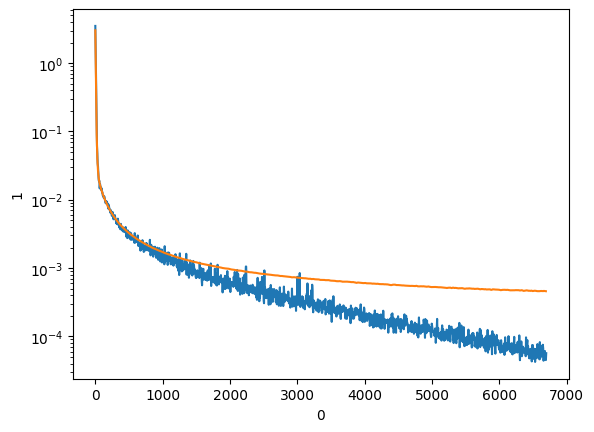

In [ ]:
idx_to_tok = {i:a for a, i in alphabet.to_dict().items()}

esm_decoder = ESMDecoder()
optimizer = torch.optim.Adam(esm_decoder.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
esm_decoder.train()

# Split data into train and test.
train_indices, test_indices =  train_test_split_indices(5000, 0.9, 0.1)
train_embeddings = torch.tensor(
    np.concatenate([out[i]["embedding"]
      for i in train_indices])
    )
train_toks = torch.tensor(
    np.concatenate([alphabet.encode(out[i]["sequence"][:1022])
      for i in train_indices])
    )
test_embeddings = torch.tensor(
    np.concatenate([out[i]["embedding"]
      for i in test_indices])
  )
test_toks = torch.tensor(
    np.concatenate([alphabet.encode(out[i]["sequence"][:1022])
      for i in test_indices])
  )

splits = mini_batch_indices(train_toks.shape[0], batch_size=20_000, n_epoch=100)
losses = []

for epoch, _indices in tqdm.tqdm(enumerate(splits)):

  batched_train_embeddings = train_embeddings[_indices]
  batched_train_toks = train_toks[_indices]

  outputs = esm_decoder(batched_train_embeddings)
  loss = loss_fn(outputs, batched_train_toks)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 5 == 0 and epoch % 10 != 0:
    losses.append([epoch, loss.item()])

  if epoch % 10 == 0:
    with torch.no_grad():
      outputs_val = esm_decoder(test_embeddings)
      loss_val = loss_fn(outputs_val, test_toks)
      optimizer.zero_grad()
    losses.append([epoch, loss.item(),loss_val.item()])
    if epoch % 500 ==0:
      print(f"Epoch {epoch}, Training Loss: {loss.item():.4f} Validation Loss: {loss_val.item():.4f}")

sns.lineplot(pd.DataFrame(losses), x=0, y=1)
sns.lineplot(pd.DataFrame(losses), x=0, y=2)
plt.yscale("log")

loss_fn(esm_decoder(torch.tensor(out[0]["embedding"])), torch.tensor(alphabet.encode(out[0]["sequence"])))

In [ ]:
for param in esm_decoder.parameters():
  print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([33, 320])
<class 'torch.nn.parameter.Parameter'> torch.Size([33])


In [ ]:
scores = []
for i in range(5000):
  _pred_seq = ''.join([idx_to_tok[i.item()] for i in esm_decoder(torch.tensor(out[i]["embedding"])).argmax(dim=1)])
  _true_seq = out[i]["sequence"][:1022]
  if _pred_seq != _true_seq:
    scores.append(i)

scores

_pred_seq = ''.join([idx_to_tok[i.item()] for i in esm_decoder(torch.tensor(out[4958]["embedding"])).argmax(dim=1)])
_true_seq = out[4958]["sequence"][:1022]
[(_,i,j) for _, (i,j) in enumerate(zip(_pred_seq, _true_seq)) if i!=j]

[(615, 'W', 'C')]

## Train decoder to map between mean-embedding and amino acid sequence.

In [ ]:
class ESM_Conditional_LSTM_Decoder(nn.Module):
  def __init__(self, alphabet_size:int = 31, latent_dim:int = 320,
               model_hidden_dim:int = 180, layers:int = 1, dropout: float = 0.1
               ):
    super().__init__()
    self.layers = layers
    self.model_hidden_dim = model_hidden_dim

    self.h0_linear = nn.Linear(latent_dim, model_hidden_dim * layers)
    self.c0_linear = nn.Linear(latent_dim, model_hidden_dim * layers)

    self.lstm = nn.LSTM(latent_dim, model_hidden_dim, layers)
    self.linear = nn.Linear(model_hidden_dim, alphabet_size)
    self.dropout = nn.Dropout(dropout)

  def init_state(self, latent):
    _, batch_size, _ = latent.shape

    h0 = self.h0_linear(latent).view(self.lstm.num_layers, batch_size, self.lstm.hidden_size).tanh() # torch.zeros((self.layers, batch_size, self.model_hidden_dim))
    c0 = self.c0_linear(latent).view(self.lstm.num_layers, batch_size, self.lstm.hidden_size).tanh() # torch.zeros((self.layers, batch_size, self.model_hidden_dim))
    return h0, c0

  def forward(self, latent, h, c, dropout=True):
    out, (h, c) = self.lstm(latent, (h, c))
    if dropout:
      out = self.dropout(out)
    logits = self.linear(out)
    return logits, h, c

  def sample(self, latent, max_length:int = 50, temp:int|None=None):
    out_seqs, out_logits = [], []
    with torch.no_grad():
      h, c = self.init_state(latent)
      for _ in range(max_length):
        logits, h, c = self.forward(latent, h, c, dropout=False)

        if temp is not None:
          logits = logits / max(temp, 1e-6)
          probs = nn.functional.softmax(logits, dim=-1).squeeze(0)
          out_seqs.append(torch.multinomial(probs, num_samples=1))
        else:
          out_seqs.append(logits.argmax(dim=-1))
        out_logits.append(logits)

    out_seqs = torch.stack(out_seqs, dim=-1).squeeze(0)
    out_logits = torch.stack(out_logits, dim=-1).squeeze(0)
    return out_seqs, out_logits

In [ ]:
class ESM_LSTM_Decoder(nn.Module):
  def __init__(self, alphabet_size: int = 31, embedding_dim: int = 320,
               hidden_dim: int = 180,
               layers: int = 3, dropout: float = 0.1, sigmoid: bool = False,
               lr: float = 1e-4, max_len=300) -> None:
    super().__init__()
    self.embedding = nn.Embedding(alphabet_size, hidden_dim)
    self.max_len = max_len
    self.lr = lr

    self.latent_to_hidden = nn.Linear(embedding_dim, hidden_dim)
    self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
    self.linear = nn.Linear(hidden_dim, alphabet_size)

  def forward(self, latent, target_sequence=None, teacher_forcing_ratio=0.9):
    batch_size = latent.shape[1]

    hidden = self.latent_to_hidden(latent)#.unsqueeze(0)  # [1, batch, hidden]
    cell = torch.zeros_like(hidden)
    inputs = torch.full((batch_size,1), 0)

    outputs=[]
    for t in range(self.max_len):
      embed = self.embedding(inputs)  # [batch, 1, embed_dim]
      out, (hidden, cell) = self.lstm(embed, (hidden, cell))
      logits = self.linear(out[:, -1, :])  # [batch, vocab_size]
      outputs.append(logits.unsqueeze(1))

      if target_sequence is not None and torch.rand(1).item() < teacher_forcing_ratio:
        print(target_sequence[:, t])
        inputs = target_sequence[:, t].unsqueeze(1)  # teacher forcing
      else:
        inputs = logits.argmax(dim=1).unsqueeze(1)

    return outputs # torch.cat(outputs, dim=1)  # [batch, seq_len, vocab_size]

# lstm_decoder = ESM_LSTM_Decoder()
# lstm_decoder(
#     embeddings[0].unsqueeze(0),
#     toks[0].unsqueeze(1)
# );

In [ ]:
def batch_encode(sequences, alphabet, max_length=1022):
  encoded_sequences = []
  _max_length = max([len(sequence) for sequence in sequences])
  max_length = min(_max_length, max_length)

  for i in range(len(sequences)):
    _encoded_seq = torch.tensor(alphabet.encode(sequences[i][:max_length]))
    _seq_length = _encoded_seq.shape[0]
    _encoded_seq = torch.nn.functional.pad(_encoded_seq, (0, max_length-_seq_length), value=0)
    encoded_sequences.append(_encoded_seq)
  return torch.stack(encoded_sequences)

batch_encode([out[i]["sequence"] for i in range(2)], alphabet=alphabet)

tensor([[20,  6, 11, 15, 23, 19,  4, 23, 13,  6,  8,  0,  0],
        [20,  5, 10, 20,  6, 13,  5,  4,  6, 22, 15,  5,  4]])

In [ ]:
import math

def batched_training_indices(n_sequence, max_length, batch_size:int=3, n_epoch:int=2):
  "Returns"
  sequence_lengths = list(range(max_length))
  sequence_indices = list(range(n_sequence))

  batched_indices = []
  for epoch in range(n_epoch):
    sequence_lengths = np.random.permutation(sequence_lengths)
    for length in sequence_lengths:
      sequence_indices = np.random.permutation(sequence_indices)
      n_splits = math.ceil(len(sequence_indices) / batch_size)
      for _batched_indices in np.array_split(sequence_indices, n_splits):
        batched_indices.append((epoch, length.item(), _batched_indices))
  return batched_indices


batched_training_indices(1, 3)

[(0, 2, array([0])),
 (0, 0, array([0])),
 (0, 1, array([0])),
 (1, 1, array([0])),
 (1, 2, array([0])),
 (1, 0, array([0]))]

In [ ]:
sequences = [out[i]["sequence"] for i in range(1000)]
embeddings = torch.tensor([out[i]["mean_embedding"] for i in range(1000)])
toks = batch_encode(sequences, alphabet=alphabet)

val_latent = embeddings[800:1000].unsqueeze(0)
val_target_toks = toks[800:1000,:50]

In [ ]:
from tqdm.notebook import tqdm
torch.manual_seed(42)

esm_decoder = ESM_Conditional_LSTM_Decoder(layers=2, dropout=0.5)
esm_decoder.train()
optimizer = torch.optim.AdamW(esm_decoder.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

max_length=50
log = {}

for epoch, sequence_length, indices in tqdm(
    batched_training_indices(800, max_length, batch_size=100, n_epoch=100),
    smoothing=0.1
    ):
  if epoch % 5 == 1 and epoch not in log:
    with torch.no_grad():
      _, val_logits = esm_decoder.sample(val_latent, max_length=max_length, temp=None)
      log[epoch-1]["val_loss"] = criterion(val_logits, val_target_toks).item()
      print(f"Epoch {epoch-1}, Loss: {np.mean(log[epoch-1]['train_loss']):.4f}, Val-Loss: {log[epoch-1]['val_loss']:.4f}")

  if epoch not in log:
    log[epoch] = {"train_loss":[]}

  _latent = embeddings[indices].unsqueeze(0)
  _previous_toks = toks[indices,:sequence_length]
  _target_toks = toks[indices,sequence_length]

  h, c = esm_decoder.init_state(_latent)
  for _ in range(sequence_length+1):
    logits, h, c = esm_decoder(_latent, h, c)
  loss = criterion(
      logits.squeeze(0),
      _target_toks
  )
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  log[epoch]["train_loss"].append(loss.item())
else:
  epoch = list(log.keys())[-1]
  with torch.no_grad():
    _, val_logits = esm_decoder.sample(val_latent, max_length=max_length, temp=None)
    log[epoch]["val_loss"] = criterion(val_logits, val_target_toks).item()
    print(f"Epoch {epoch}, Loss: {np.mean(log[epoch]['train_loss']):.4f}, Val-Loss: {log[epoch]['val_loss']:.4f}")

  0%|          | 0/40000 [00:00<?, ?it/s]

Epoch 0, Loss: 2.9514, Val-Loss: 2.9691
Epoch 5, Loss: 2.6311, Val-Loss: 2.7789
Epoch 10, Loss: 2.5737, Val-Loss: 2.7831
Epoch 15, Loss: 2.5442, Val-Loss: 2.7810
Epoch 20, Loss: 2.4987, Val-Loss: 2.7792
Epoch 25, Loss: 2.4540, Val-Loss: 2.8179
Epoch 30, Loss: 2.4147, Val-Loss: 2.8349
Epoch 35, Loss: 2.3653, Val-Loss: 2.8675


In [ ]:
''
torch.manual_seed(42)

esm_decoder = ESM_Conditional_LSTM_Decoder(layers=1)
esm_decoder.train()
optimizer = torch.optim.AdamW(esm_decoder.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
  latent = embeddings.unsqueeze(0)[:,:30]
  toks = batch_encode([out[i]["sequence"] for i in range(30)], alphabet=alphabet)
  _, max_length = toks.shape

  for j in range(50):
    h, c = esm_decoder.init_state(latent)
    for i in range(50): # toks.shape[-1]
      optimizer.zero_grad()
      logits, h, c = esm_decoder(latent, h, c)
      # print(logits.squeeze(0).shape, toks[:, i])
      loss = criterion(
          logits.squeeze(0),
          toks[:,i]
      )
      # print(j, i, toks[:,i].item(), logits.squeeze(1).argmax().item())

      if i == j:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        break
      # print(f"Epoch {epoch}, Loss: {loss.item():.4f}"
  if epoch % 10 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 2.8962
Epoch 10, Loss: 2.7337
Epoch 20, Loss: 2.5275
Epoch 30, Loss: 2.6136
Epoch 40, Loss: 2.1158


In [ ]:
latent = embeddings.unsqueeze(0)[:,:500]
toks = batch_encode([out[i]["sequence"] for i in range(500)], alphabet=alphabet)

accuracy = []
for i in range(500):
  pred_seq = esm_decoder.sample(latent[:,i,:].unsqueeze(1), max_length=10, temp=None)
  true_seq = toks[i,:10]
  _accuracy = (pred_seq == true_seq).sum()/10
  sample = "Test" if i >= 30 else "Train"
  accuracy.append({"Sample":sample, "Accuracy":_accuracy.item()})

accuracy_df = pd.DataFrame(accuracy)
sns.histplot(accuracy_df, x="Accuracy", hue="Sample")

AttributeError: 'bool' object has no attribute 'sum'

In [ ]:
pred_seqs, _ = esm_decoder.sample(embeddings.unsqueeze(0), max_length=50)
(pred_seqs == toks[:1000,:50]).sum(dim=1)

tensor([42, 40, 34, 35, 36, 33, 32, 30, 30, 34, 33, 28, 30, 25, 31, 31, 28, 29,
        30, 25, 30, 23, 26, 24, 25, 22, 23, 21, 25, 25, 25, 22, 26, 24, 24, 23,
        23, 26, 22, 23, 20, 25, 23, 20, 22, 21, 18, 22, 21, 19, 19, 17, 21, 22,
        19, 17, 24, 18, 17, 20, 20, 16, 21, 24, 20, 17, 11, 20, 21, 17, 21, 14,
        19, 20, 19, 20, 11, 17, 16, 17, 15, 15, 16, 14, 19, 13, 15, 17, 15, 12,
        16, 17, 17, 15, 12, 13, 16, 35, 19, 15, 21, 19, 10, 22, 14, 24, 15, 16,
        20, 11, 20, 18, 11,  7, 14, 14,  7, 13, 14, 11, 10, 11, 10,  9, 17,  8,
         7,  6, 16, 12,  7,  5,  9,  8,  7, 11,  8, 10,  7,  6, 10, 10,  7,  5,
        10, 13,  8,  9,  7,  8, 11,  8,  8, 10,  6,  8,  9,  8,  8,  5,  8,  6,
         8, 10,  7,  8, 15,  8,  5, 10,  6,  7,  7, 10,  5,  5,  8,  6,  8,  7,
        10,  5,  8, 10, 12, 13, 12, 11,  9,  8,  7,  9,  9, 11, 12,  5, 12, 13,
         7,  7,  7,  5,  7, 12,  8, 13,  8,  5,  6, 13, 10, 10, 10,  8,  8,  7,
         7,  7,  8,  6, 11,  9,  8,  7, 

In [ ]:
x = torch.tensor([20])
y = torch.tensor([1])
z = torch.tensor([2])
torch.stack((x,y,z), dim=-1)

tensor([[20,  1,  2]])